In [1]:
#Imports
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FormatStrFormatter
from scipy.optimize import curve_fit
import pandas as pd
import scipy.stats as stats 
import matplotlib.colors as mcolors
import matplotlib.lines as mlines
import tkinter as tk
from tkinter import filedialog
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.colors import ListedColormap
import matplotlib.cm as cm
from matplotlib.ticker import MaxNLocator
from scipy.signal import find_peaks
from scipy.ndimage import gaussian_filter1d
from tqdm import tqdm
import glob
from pathlib import Path

In [2]:
import calcFunctions as calcFunc
import inputsOutputsFunctions as inpOutsFunc

In [3]:
ROOT_PATH=Path.cwd()/'SPVGrainBoundaries'

In [4]:
testDIr = ROOT_PATH/"npy files"/"Passivated"/"FullImages_CPDandSPV"

In [5]:
images = glob.glob(f"{testDIr}/**/**/*.npy",recursive=True)
images

['c:\\Users\\zero123455\\Desktop\\KPFMShorten\\SPVGrainBoundaries\\npy files\\Passivated\\FullImages_CPDandSPV\\Dark_CPD.npy',
 'c:\\Users\\zero123455\\Desktop\\KPFMShorten\\SPVGrainBoundaries\\npy files\\Passivated\\FullImages_CPDandSPV\\LightOff_CPD.npy',
 'c:\\Users\\zero123455\\Desktop\\KPFMShorten\\SPVGrainBoundaries\\npy files\\Passivated\\FullImages_CPDandSPV\\LightOff_SPV.npy',
 'c:\\Users\\zero123455\\Desktop\\KPFMShorten\\SPVGrainBoundaries\\npy files\\Passivated\\FullImages_CPDandSPV\\LightOn_CPD.npy',
 'c:\\Users\\zero123455\\Desktop\\KPFMShorten\\SPVGrainBoundaries\\npy files\\Passivated\\FullImages_CPDandSPV\\LightOn_SPV.npy']

In [6]:
def loadAllMasks(maskDir:str)->pd.DataFrame:
    maskDict={}
    for i in glob.glob(f"{maskDir}/**/**/*.npy",recursive=True):
        maskDict[os.path.basename(i.split('.')[0])]=np.load(i)
    return pd.DataFrame({"masks_name":maskDict.keys(),"masks":maskDict.values()})

In [7]:
def extractInternalAndBoundaryMasks(mask:np.array,imageData:np.array)->np.array:
    return imageData*mask,imageData*(-mask+1)

In [8]:
def generateInternalExternal(masks:pd.DataFrame,imagePath:Path)->pd.DataFrame:
    imageData = np.load(imagePath)
    boundaries = []
    internals = []
    for i in masks["masks_name"]:
        boundary,internal = extractInternalAndBoundaryMasks(*masks.query("masks_name == @i")["masks"].to_numpy(),imageData)
        boundaries.append(boundary)
        internals.append(internal)
    
    grainData = {}
    grainData["boundaries"]=boundaries
    grainData["internals"]=internals
    return pd.DataFrame(grainData)

In [9]:
def generateHistograms(dataFrame:pd.DataFrame)->pd.DataFrame:
    bound_x_data = []
    bound_voltage = []
    intern_x_data = []
    intern_voltage = []

    for i,dataSubset in dataFrame.iterrows():
        data = dataSubset["boundaries"]
        x_data,voltage = np.histogram(data[np.where(data!=0)],bins='auto')
        bound_x_data.append(x_data)
        bound_voltage.append(voltage)

        data = dataSubset["internals"]
        x_data,voltage = np.histogram(data[np.where(data!=0)],bins='auto')
        intern_x_data.append(x_data)
        intern_voltage.append(voltage)
    
    dataFrame["bound_x_data"]=bound_x_data
    dataFrame["bound_voltage"]=bound_voltage
    dataFrame["intern_x_data"]=intern_x_data
    dataFrame["intern_voltage"]=intern_voltage
    return dataFrame

In [10]:
testMask = ROOT_PATH/"npy files"/"Passivated"/"Masks"
masks = loadAllMasks(testMask)

In [11]:
calculatedData = {}
for i in images:
    calculatedData[Path(i).name] = generateInternalExternal(masks,i)
    calculatedData[Path(i).name] = generateHistograms(calculatedData[Path(i).name])

In [12]:
calculatedData.keys()

dict_keys(['Dark_CPD.npy', 'LightOff_CPD.npy', 'LightOff_SPV.npy', 'LightOn_CPD.npy', 'LightOn_SPV.npy'])

In [13]:
calculatedData['Dark_CPD.npy']

,boundaries,internals,bound_x_data,bound_voltage,intern_x_data,intern_voltage
0,"[[-0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0...","[[-0.6629955768585205, -0.6634938716888428, -0...","[3, 1, 3, 3, 8, 8, 19, 30, 40, 49, 70, 92, 141...","[-0.6786024570465088, -0.6778808780338453, -0....","[2, 0, 6, 6, 13, 7, 13, 21, 29, 32, 31, 42, 54...","[-0.6796121597290039, -0.6792139605189977, -0...."
1,"[[-0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0...","[[-0.6629955768585205, -0.6634938716888428, -0...","[1, 1, 5, 2, 3, 6, 10, 11, 14, 17, 30, 43, 47,...","[-0.6796121597290039, -0.6790917208700469, -0....","[1, 4, 5, 13, 7, 15, 20, 25, 31, 32, 46, 51, 7...","[-0.6793534755706787, -0.6789137125015259, -0...."
2,"[[-0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0...","[[-0.6629955768585205, -0.6634938716888428, -0...","[2, 0, 4, 6, 4, 6, 8, 15, 12, 20, 21, 30, 48, ...","[-0.6796121597290039, -0.6791578042201507, -0....","[5, 7, 10, 13, 16, 26, 26, 35, 43, 60, 59, 65,...","[-0.6787669658660889, -0.6782668303040897, -0...."
3,"[[-0.6629955768585205, -0.0, -0.0, -0.0, -0.0,...","[[-0.0, -0.6634938716888428, -0.66557049751281...","[2, 0, 5, 6, 9, 2, 9, 18, 16, 22, 27, 32, 36, ...","[-0.6796121597290039, -0.6791952217326445, -0....","[4, 9, 5, 18, 19, 18, 32, 41, 42, 43, 65, 84, ...","[-0.6786584854125977, -0.6780736663124778, -0...."
4,"[[-0.6629955768585205, -0.6634938716888428, -0...","[[-0.0, -0.0, -0.6655704975128174, -0.66679120...","[2, 0, 6, 6, 10, 4, 7, 18, 27, 25, 31, 35, 46,...","[-0.6796121597290039, -0.6792139605189977, -0....","[3, 7, 11, 13, 10, 22, 21, 34, 34, 55, 76, 100...","[-0.6786584854125977, -0.6779413167820421, -0...."


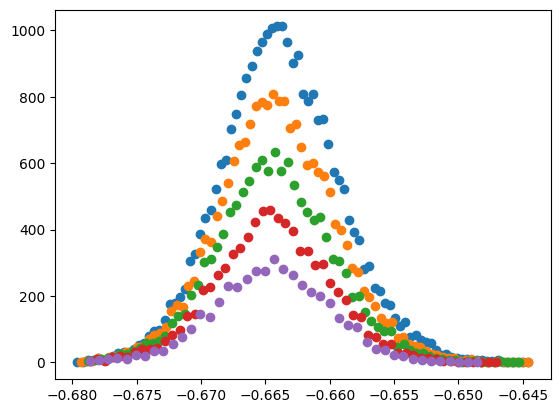

In [ ]:
for ind,data in enumerate(calculatedData['Dark_CPD.npy'][["intern_x_data","intern_voltage"]].to_numpy()):
    xdata,voltage = data
    plt.scatter(voltage[:-1],xdata,label=f"pixel {ind}")


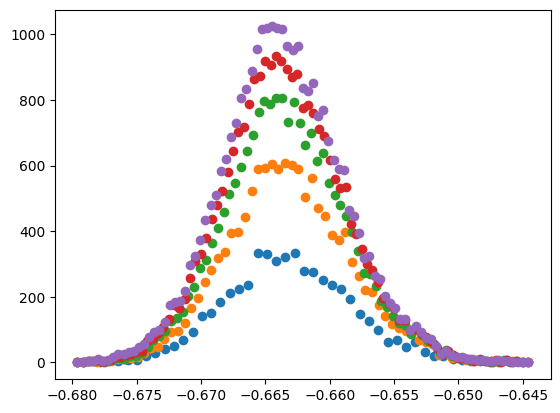

In [14]:
for ind,data in enumerate(calculatedData['Dark_CPD.npy'][["bound_x_data","bound_voltage"]].to_numpy()):
    xdata,voltage = data
    plt.scatter(voltage[:-1],xdata,label=f"pixel {ind}")

In [15]:
Colours={"unpassivated":{'colour1': "#5CBBFF", 'colour2': "#003357"},
         "passivated":{'colour1': "#D69AAB", 'colour2': "#8D1730"}}

In [28]:
calculatedData.keys()

dict_keys(['Dark_CPD.npy', 'LightOff_CPD.npy', 'LightOff_SPV.npy', 'LightOn_CPD.npy', 'LightOn_SPV.npy'])

In [31]:
storageDir = Path.cwd()/"testSingleGaussianPlots"
os.makedirs(storageDir, exist_ok=True)
for key in calculatedData:
    save_path = storageDir/f"{key.split('.')[0]}"
    os.makedirs(save_path, exist_ok=True)
    subset = calculatedData[key]
    datatype = key.split('_')[1].split('.')[0]
    y_peaks_adjusted = []
    for ind,data in subset.iterrows():
        GB_x_raw_1, GB_y_raw_1, GB_x_1, GB_y_1, GB_peak_1, GB_fwhm_1 = calcFunc.fit_gaussian(data["bound_voltage"][:-1],data["bound_x_data"])
        GI_x_raw_1, GI_y_raw_1, GI_x_1, GI_y_1, GI_peak_1, GI_fwhm_1 = calcFunc.fit_gaussian(data["intern_voltage"][:-1],data["intern_x_data"])
        peak_diff_1 = (GB_peak_1 - GI_peak_1)*1000
        
        
        inpOutsFunc.storeAnalysis(GB_peak_1,GB_fwhm_1,0,0,GI_peak_1,GI_fwhm_1,0,0,peak_diff_1,save_path,ind,scaleFactor=1000)
        # #Adjusting arrays to give results in mV
        GB_x_raw = np.round(GB_x_raw_1*1000,4)
        GI_x_raw = np.round(GI_x_raw_1*1000,4)
        GB_x_fit= np.round(GB_x_1*1000,4)
        GI_x_fit= np.round(GI_x_1*1000,4)

        
        # # Plotting functions: 
        inpOutsFunc.generateFigures(GB_x_raw,GB_x_fit,GI_x_raw,GI_x_fit,GB_y_raw_1,GB_y_1,GI_y_raw_1,GI_y_1,Colours["passivated"]["colour1"],Colours["passivated"]["colour2"],save_path,datatype,ind)
        y_peaks_adjusted.append(round(peak_diff_1,4))
    
    subset["y_peaks_adjusted"] = np.asarray(y_peaks_adjusted)

In [20]:
testPth = Path.cwd()/"SPVGrainBoundaries"/"OLDSPVtxtfiles_compatiblewithcurrent"/"passivated"/"Dark_CPD"/"GB"

In [21]:
GB1 = np.loadtxt(f"{testPth}/1.txt",skiprows=3,encoding='utf-8',unpack=True)

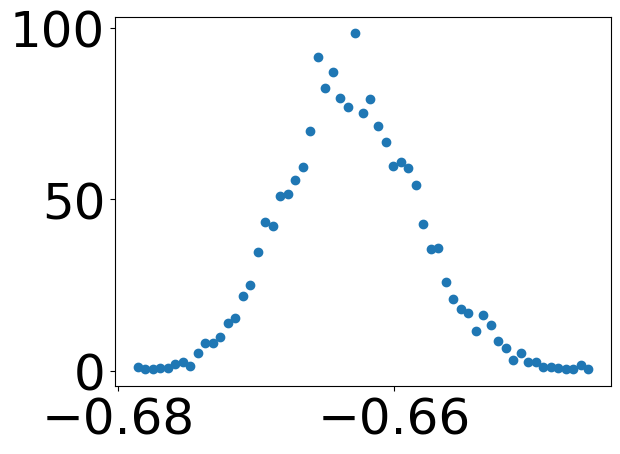

In [22]:
plt.scatter(GB1[0,:],GB1[1,:])

In [23]:
popt, pcov = curve_fit(calcFunc.gaussian, GB1[0,:],GB1[1,:], maxfev=100000000)
scales=popt[0]
mus=popt[1]
sigmas=pcov[1,1]

In [24]:
print(scales)
print(mus)
print(sigmas)

84.32017769668249
-0.6633529110106648
7.367090307876598e-09
